In [1]:
import gc
import sklearn
import imblearn
import numpy as np
import keras_tuner
import tensorflow as tf
from collections import Counter
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import os

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

if parent_dir not in sys.path:
    sys.path.append(parent_dir)

import Modules.constants as constants 
import Modules.ds_loader as ds_loader

DATA_PATH = ".."/constants.DATASET

X_train, y_train = ds_loader.load_data(DATA_PATH / "train")
X_test, y_test = ds_loader.load_data(DATA_PATH / "test")
X_val, y_val = ds_loader.load_data(DATA_PATH / "val")

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

2025-04-15 03:39:23.582851: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-15 03:39:23.592988: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744681163.603808  121040 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744681163.607335  121040 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744681163.617303  121040 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

[ OK ] Loaded 7408 samples with shape (250, 12)
[ OK ] Loaded 1589 samples with shape (250, 12)
[ OK ] Loaded 1590 samples with shape (250, 12)


In [2]:
print("Unique classes in y:", np.unique(y_train))
print("Datatype:", print(X_train.dtype), print(y_train.dtype))
print(f"Min and Max of X_train: {np.min(X_train)}, {np.max(X_train)}")
print(f"Min and Max of X_val: {np.min(X_val)}, {np.max(X_val)}")
print(f"Min and Max of X_test: {np.min(X_test)}, {np.max(X_test)}")
print(f"NaNs in X: {np.isnan(X_train).sum()}")
print(f"Infs in X: {np.isinf(X_train).sum()}")
print(f"Class distribution: {Counter(y_train)}")

Unique classes in y: [0 1 2 3]
float32
int32
Datatype: None None
Min and Max of X_train: 0.0, 1.0000001192092896
Min and Max of X_val: -15.150476455688477, 16.52423667907715
Min and Max of X_test: -16.605043411254883, 22.70928955078125
NaNs in X: 0
Infs in X: 0
Class distribution: Counter({np.int32(2): 2721, np.int32(1): 1582, np.int32(3): 1554, np.int32(0): 1551})


In [3]:
X_train_flat = X_train.reshape((X_train.shape[0],-1))
smote = imblearn.over_sampling.SMOTE(random_state=42)
X_resampled, y_train = smote.fit_resample(X_train_flat, y_train)
X_train = X_resampled.reshape((-1, *X_train.shape[1:]))

print(f"Class distribution: {Counter(y_train)}")

Class distribution: Counter({np.int32(0): 2721, np.int32(1): 2721, np.int32(2): 2721, np.int32(3): 2721})


In [4]:
"""# 1-D convolutional ResNet model 
# https://pmc.ncbi.nlm.nih.gov/articles/PMC10128986/#sec012
class Resnet(keras_tuner.HyperModel):
    def residual_block(self, inputs, c_units, p_units, k_units):
        # C1 BLOCK
        x = tf.keras.layers.Conv1D(filters=c_units, kernel_size=k_units, strides=1, padding='same')(inputs)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.BatchNormalization()(x)
        
        x = tf.keras.layers.Conv1D(filters=c_units, kernel_size=k_units, strides=1, padding='same')(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.BatchNormalization()(x)
        # SC
        s = tf.keras.layers.Conv1D(filters=c_units, kernel_size=1, strides=1, padding='same')(inputs)
        x = tf.keras.layers.Add()([x, s])
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.MaxPooling1D(p_units, strides=2)(x)
        return x


    def build(self, hp):
        gc.collect()
        tf.keras.backend.clear_session()
        # HYPERPARAMS
        n_layer = 3
        k_units = 3
        p_units = 5

        c_units = hp.Choice("c_units", [64])
        d_units_0 = hp.Choice("d_units_0", [1024])
        d_units_1 = hp.Choice('d_units_coef', [2,4,8])
        dropout_0 = hp.Float('dropout_0', min_value = 0.3, max_value=0.5, step=0.05)
        dropout_1 = hp.Float('dropout_1', min_value = 0.3, max_value=0.5, step=0.05)
        
        # INPUT LAYER
        inputs = tf.keras.Input(shape=(500,12))
        
        # RESIDUALS
        x = self.residual_block(inputs, c_units, p_units, k_units)
        filter_size = c_units
        for i in range(1, n_layer):
            filter_size *= 2  
            x = self.residual_block(x, filter_size, p_units, k_units)

        # CLASSIFIER
        x = tf.keras.layers.Flatten()(x)
        x = tf.keras.layers.Dense(d_units_0, activation='relu')(x)
        x = tf.keras.layers.Dropout(dropout_0)(x)  
        x = tf.keras.layers.Dense(d_units_0 // d_units_1, activation='relu')(x)
        x = tf.keras.layers.Dropout(dropout_1)(x)  

        # OUTPUT
        outputs = tf.keras.layers.Dense(4, activation='softmax')(x)
        
        model = tf.keras.Model(inputs, outputs)
        optimizer = tf.keras.optimizers.Adam(
                        learning_rate=hp.Float('learning_rate', min_value=1e-4, max_value=1e-3),
                        weight_decay=hp.Choice('weight_decay',[1e-3,1e-4,1e-5,0.0])
                    )
        model.compile(
            optimizer=optimizer,
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )
        
        
        return model
    
    def fit(self, hp, model, *args, **kwargs):
        return model.fit(
            batch_size= hp.Choice("batch_size", [32]),
            *args,
            **kwargs,
        ) """

'# 1-D convolutional ResNet model \n# https://pmc.ncbi.nlm.nih.gov/articles/PMC10128986/#sec012\nclass Resnet(keras_tuner.HyperModel):\n    def residual_block(self, inputs, c_units, p_units, k_units):\n        # C1 BLOCK\n        x = tf.keras.layers.Conv1D(filters=c_units, kernel_size=k_units, strides=1, padding=\'same\')(inputs)\n        x = tf.keras.layers.ReLU()(x)\n        x = tf.keras.layers.BatchNormalization()(x)\n\n        x = tf.keras.layers.Conv1D(filters=c_units, kernel_size=k_units, strides=1, padding=\'same\')(x)\n        x = tf.keras.layers.ReLU()(x)\n        x = tf.keras.layers.BatchNormalization()(x)\n        # SC\n        s = tf.keras.layers.Conv1D(filters=c_units, kernel_size=1, strides=1, padding=\'same\')(inputs)\n        x = tf.keras.layers.Add()([x, s])\n        x = tf.keras.layers.ReLU()(x)\n        x = tf.keras.layers.BatchNormalization()(x)\n        x = tf.keras.layers.MaxPooling1D(p_units, strides=2)(x)\n        return x\n\n\n    def build(self, hp):\n        

In [ ]:
# 1-D convolutional ResNet model 
# https://pmc.ncbi.nlm.nih.gov/articles/PMC10128986/#sec012
class Resnet(keras_tuner.HyperModel):
    def residual_block(self, inputs, c_units, p_units, k_units):
        # C1 BLOCK
        x = tf.keras.layers.Conv1D(filters=c_units, kernel_size=6, strides=1, padding='same')(inputs)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.MaxPooling1D(6, 6, padding="same")(x)
        x = tf.keras.layers.Conv1D(filters=c_units, kernel_size=k_units, strides=1, padding='same')(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.MaxPooling1D(p_units, p_units, padding="same")(x)
        x = tf.keras.layers.Conv1D(filters=c_units, kernel_size=k_units, strides=1, padding='same')(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.MaxPooling1D(p_units, p_units, padding="same")(x)
    
        return x


    def build(self, hp):
        gc.collect()
        tf.keras.backend.clear_session()
        # HYPERPARAMS
        n_layer = 1
        k_units = 3
        p_units = 3

        c_units = hp.Choice("c_units", [32])
        d_units_0 = hp.Choice("d_units_0", [64])
        d_units_1 = hp.Choice('d_units_coef', [2])
        dropout_0 = hp.Float('dropout_0', min_value = 0.3, max_value=0.5, step=0.05)
        dropout_1 = hp.Float('dropout_1', min_value = 0.3, max_value=0.5, step=0.05)
        
        # INPUT LAYER
        inputs = tf.keras.Input(shape=(5000//constants.WINDOW_SIZE,12))
        
        # RESIDUALS
        x = self.residual_block(inputs, c_units, p_units, k_units)
        filter_size = c_units
        for i in range(1, n_layer):
            #filter_size *= 2  
            x = self.residual_block(x, filter_size, p_units, k_units)

        # CLASSIFIER
        x = tf.keras.layers.Flatten()(x)
        x = tf.keras.layers.Dense(d_units_0, activation='relu')(x)
        x = tf.keras.layers.Dropout(dropout_0)(x)  
        x = tf.keras.layers.Dense(d_units_0 // d_units_1, activation='relu')(x)
        x = tf.keras.layers.Dropout(dropout_1)(x)  

        # OUTPUT
        outputs = tf.keras.layers.Dense(4, activation='softmax')(x)
        
        model = tf.keras.Model(inputs, outputs)
        optimizer = tf.keras.optimizers.Adam(
                        learning_rate=hp.Float('learning_rate', min_value=1e-5, max_value=1e-3),
                        weight_decay=hp.Choice('weight_decay',[1e-3,1e-4,1e-5,0.0])
                    )
        model.compile(
            optimizer=optimizer,
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )
        
        
        return model
    
    def fit(self, hp, model, *args, **kwargs):
        return model.fit(
            batch_size= hp.Choice("batch_size", [32]),
            *args,
            **kwargs,
        ) 

In [ ]:
RDIR="src/Results/RES_W500_L33/" 
MDIR= RDIR + "RES_W500_L33.keras"
CDIR= RDIR + "C_RES_W500_L33.keras"
CVDIR = RDIR + "RES_W500_L33_CV.keras"
tuner = keras_tuner.BayesianOptimization(
    Resnet(),
    max_trials=20,
    overwrite=True,
    objective='val_accuracy',
    directory=RDIR,
    project_name="RES_W5000_L33",
    )

tuner.search_space_summary()

I0000 00:00:1744681170.928753  121040 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1896 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Search space summary
Default search space size: 7
c_units (Choice)
{'default': 32, 'conditions': [], 'values': [32], 'ordered': True}
d_units_0 (Choice)
{'default': 64, 'conditions': [], 'values': [64], 'ordered': True}
d_units_coef (Choice)
{'default': 2, 'conditions': [], 'values': [2], 'ordered': True}
dropout_0 (Float)
{'default': 0.3, 'conditions': [], 'min_value': 0.3, 'max_value': 0.5, 'step': 0.05, 'sampling': 'linear'}
dropout_1 (Float)
{'default': 0.3, 'conditions': [], 'min_value': 0.3, 'max_value': 0.5, 'step': 0.05, 'sampling': 'linear'}
learning_rate (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-05, 'max_value': 0.001, 'step': None, 'sampling': 'linear'}
weight_decay (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0001, 1e-05, 0.0], 'ordered': True}


In [7]:
callback_list = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy",mode="max", restore_best_weights=True,patience=5, verbose=0),
    tf.keras.callbacks.ModelCheckpoint(filepath=CDIR,monitor='val_accuracy', save_best_only=True, save_weights_only=False,    
    verbose=0)
]
tuner.search(
    X_train, y_train, 
    epochs = 150,
    validation_data=(X_val, y_val),
    callbacks=callback_list 
)

Trial 20 Complete [00h 00m 22s]
val_accuracy: 0.8660377264022827

Best val_accuracy So Far: 0.8716981410980225
Total elapsed time: 00h 07m 05s


In [8]:
tuner.results_summary()

Results summary
Results in ../Results/RES_W500_L33/RES_W5000_L33
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 01 summary
Hyperparameters:
c_units: 32
d_units_0: 64
d_units_coef: 2
dropout_0: 0.45
dropout_1: 0.4
learning_rate: 0.0006986198524476649
weight_decay: 0.001
batch_size: 32
Score: 0.8716981410980225

Trial 06 summary
Hyperparameters:
c_units: 32
d_units_0: 64
d_units_coef: 2
dropout_0: 0.5
dropout_1: 0.45
learning_rate: 0.0009713199665270937
weight_decay: 1e-05
batch_size: 32
Score: 0.8660377264022827

Trial 19 summary
Hyperparameters:
c_units: 32
d_units_0: 64
d_units_coef: 2
dropout_0: 0.4
dropout_1: 0.35
learning_rate: 0.0008502517754490445
weight_decay: 1e-05
batch_size: 32
Score: 0.8660377264022827

Trial 14 summary
Hyperparameters:
c_units: 32
d_units_0: 64
d_units_coef: 2
dropout_0: 0.3
dropout_1: 0.3
learning_rate: 0.0007485332426572175
weight_decay: 0.0001
batch_size: 32
Score: 0.8628931045532227

Trial 18 summary
Hyperparameters:
c_uni

In [9]:
models = tuner.get_best_models(num_models=1)
best_model = models[0]
best_model.summary()
best_model.save(MDIR) 

/home/capitan/.venv/tenv/lib64/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 250, 12)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 250, 32)        │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 250, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 250, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 42, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 42, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 42, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 42, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 14, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,444 (83.77 KB)

 Trainable params: 21,252 (83.02 KB)

 Non-trainable params: 192 (768.00 B)

In [10]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0] 
print(best_hps.values)

{'c_units': 32, 'd_units_0': 64, 'd_units_coef': 2, 'dropout_0': 0.45, 'dropout_1': 0.4, 'learning_rate': 0.0006986198524476649, 'weight_decay': 0.001, 'batch_size': 32}


In [11]:
test_loss, test_accuracy = best_model.evaluate(X_test, y_test, batch_size=32)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8458 - loss: 0.5611
Test Loss: 0.48828765749931335
Test Accuracy: 0.8728760480880737


In [12]:
y_pred = best_model.predict(X_test)

if y_pred.shape[1] == 1:  
    y_pred_binary = (y_pred > 0.5).astype(int)
    auc = sklearn.metrics.roc_auc_score(y_test, y_pred)  
else:
    y_pred_binary = np.argmax(y_pred, axis=1)  
    auc = sklearn.metrics.roc_auc_score(y_test, y_pred, multi_class='ovr')

print("Classification Report (Test Data):")
print(sklearn.metrics.classification_report(y_test, y_pred_binary))
print(f"AUC: {auc}")

y_train_pred = best_model.predict(X_train)
y_train_pred = np.argmax(y_train_pred, axis=1)

print("Classification Report (Train Data):")
print(sklearn.metrics.classification_report(y_train, y_train_pred))

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step 
Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.73      0.81      0.77       333
           1       0.86      0.79      0.83       338
           2       0.92      0.99      0.96       584
           3       0.96      0.81      0.88       334

    accuracy                           0.87      1589
   macro avg       0.87      0.85      0.86      1589
weighted avg       0.88      0.87      0.87      1589

AUC: 0.9719082309393074
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Classification Report (Train Data):
              precision    recall  f1-score   support

           0       0.93      0.87      0.90      2721
           1       0.90      0.95      0.92      2721
           2       0.97      0.99      0.98      2721
           3       0.97      0.96      0.97      2721

    accuracy                           0.94     10884
   macro avg       0.94      0.94      0.94     10884
weighted 

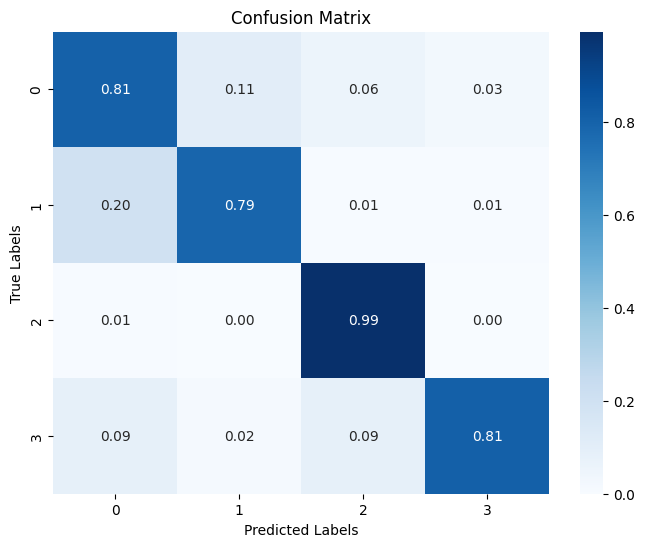

In [13]:
import seaborn as sns
y_pred_class = np.argmax(y_pred, axis=1)  
cm = sklearn.metrics.confusion_matrix(y_test, y_pred_class, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [14]:
kfold = sklearn.model_selection.StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
fold_accuracies = []
fold_histories = []

best_accuracy = 0.0
best_model = None  

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train)):
    print(f"\n--- Fold {fold+1} ---")

    fold_callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True)
    ]
    X_tr, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_tr, y_val_fold = y_train[train_idx], y_train[val_idx]

    model = Resnet().build(best_hps)

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100,
        callbacks=fold_callbacks,
        verbose=1
    )

    val_loss, val_accuracy = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    print(f"Fold {fold+1} Validation Accuracy: {val_accuracy:.4f}")
    fold_accuracies.append(val_accuracy)
    fold_histories.append(history)

    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        best_model = model
        model.save(CVDIR) 
        print(f"Saved best model from Fold {fold+1} with Accuracy: {val_accuracy:.4f}")



--- Fold 1 ---
Epoch 1/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.3318 - loss: 1.6458 - val_accuracy: 0.6042 - val_loss: 1.0262
Epoch 2/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5757 - loss: 0.9927 - val_accuracy: 0.6612 - val_loss: 0.7702
Epoch 3/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7049 - loss: 0.7355 - val_accuracy: 0.8062 - val_loss: 0.5134
Epoch 4/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7813 - loss: 0.5819 - val_accuracy: 0.8246 - val_loss: 0.4721
Epoch 5/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8087 - loss: 0.4985 - val_accuracy: 0.7759 - val_loss: 0.5708
Epoch 6/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8356 - loss: 0.4457 - val_accuracy: 0.8623 - val_loss: 0.3399
Epoch 7/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8721 - loss: 0.3701 - val_accuracy: 0.8806 - val_loss: 0.3242
Epoch 8/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8738 - loss: 

In [15]:
print("Cross-validation accuracies:", fold_accuracies)
print("Average CV accuracy:", np.mean(fold_accuracies))
print("Max CV accuracy:", np.max(fold_accuracies))

Cross-validation accuracies: [0.9219467639923096, 0.939393937587738, 0.9595959782600403, 0.9292929172515869, 0.9191176295280457, 0.8979779481887817, 0.9384191036224365, 0.920036792755127, 0.9264705777168274, 0.9172794222831726]
Average CV accuracy: 0.9269531071186066
Max CV accuracy: 0.9595959782600403


In [16]:
cv_model = tf.keras.models.load_model(CVDIR)
cv_model.evaluate(X_test, y_test)

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7212 - loss: 3.9292


[2.153379440307617, 0.8281938433647156]

In [17]:
test_loss, test_accuracy = cv_model.evaluate(X_test, y_test, batch_size=32)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7212 - loss: 3.9292
Test Loss: 2.153379440307617
Test Accuracy: 0.8281938433647156


In [18]:
y_pred = cv_model.predict(X_test)

if y_pred.shape[1] == 1:  
    y_pred_binary = (y_pred > 0.5).astype(int)
    auc = sklearn.metrics.roc_auc_score(y_test, y_pred)  
else:
    y_pred_binary = np.argmax(y_pred, axis=1)  
    auc = sklearn.metrics.roc_auc_score(y_test, y_pred, multi_class='ovr')

print("Classification Report (Test Data):")
print(sklearn.metrics.classification_report(y_test, y_pred_binary))
print(f"AUC: {auc}")

y_train_pred = cv_model.predict(X_train)
y_train_pred = np.argmax(y_train_pred, axis=1)

print("Classification Report (Train Data):")
print(sklearn.metrics.classification_report(y_train, y_train_pred))

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step 
Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.80      0.51      0.62       333
           1       0.68      0.91      0.78       338
           2       0.93      0.98      0.95       584
           3       0.88      0.80      0.84       334

    accuracy                           0.83      1589
   macro avg       0.82      0.80      0.80      1589
weighted avg       0.84      0.83      0.82      1589

AUC: 0.9404891113763643
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Classification Report (Train Data):
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      2721
           1       0.99      0.97      0.98      2721
           2       1.00      0.99      1.00      2721
           3       1.00      0.99      0.99      2721

    accuracy                           0.99     10884
   macro avg       0.99      0.99      0.99     10884
weighted 

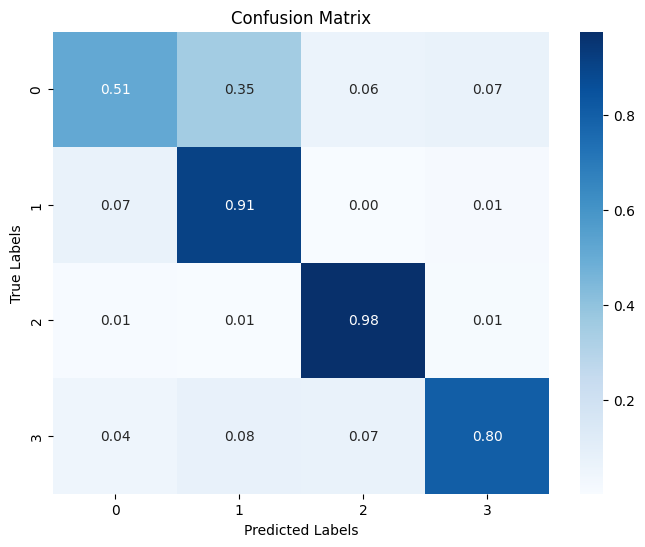

In [19]:
import seaborn as sns
y_pred_class = np.argmax(y_pred, axis=1)  
cm = sklearn.metrics.confusion_matrix(y_test, y_pred_class, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

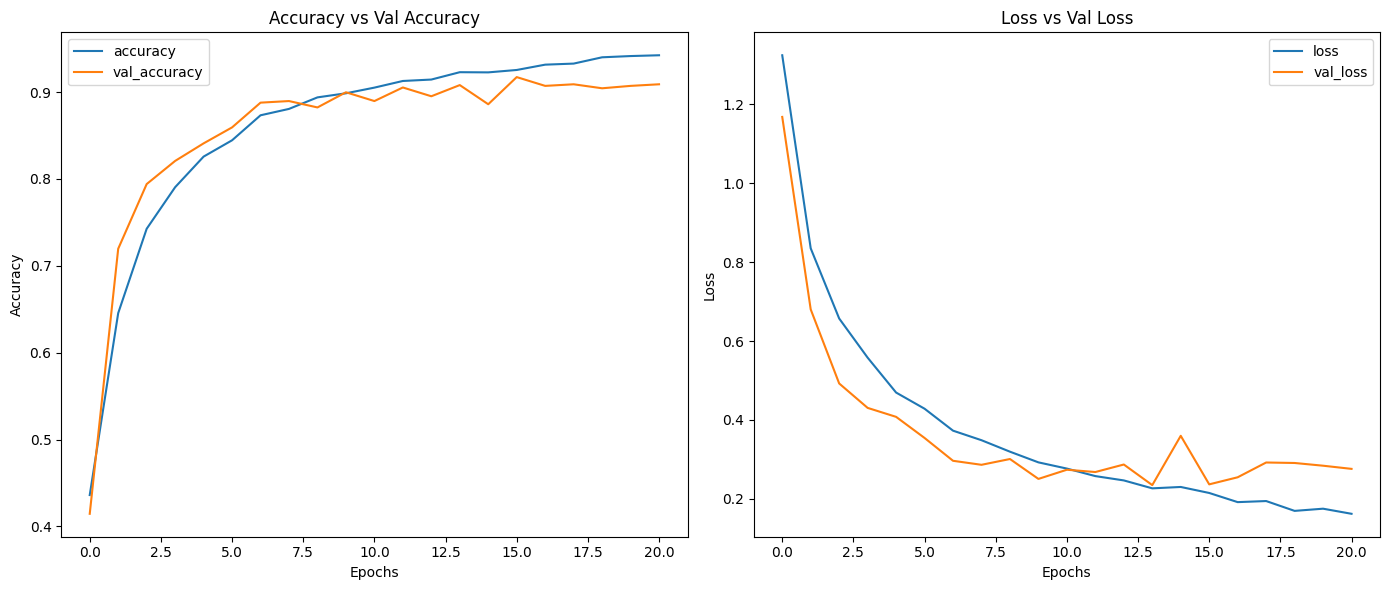

In [20]:

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].plot(history.history['accuracy'], label='accuracy')
ax[0].plot(history.history['val_accuracy'], label='val_accuracy')
ax[0].set_title('Accuracy vs Val Accuracy')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

ax[1].plot(history.history['loss'], label='loss')
ax[1].plot(history.history['val_loss'], label='val_loss')
ax[1].set_title('Loss vs Val Loss')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.tight_layout()
plt.show()